In [2]:
import pickle as pkl
import mplhep as hep
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(1, "../")
from tools import binning
from utils.merge_helpers import *

/home/cms-jovyan/GluonJetMass/unfold/notebooks/../utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/home/cms-jovyan/GluonJetMass/unfold/notebooks/../utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():


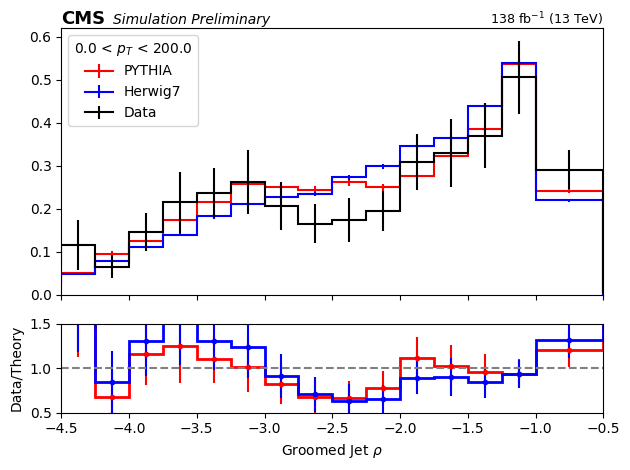

/home/cms-jovyan/GluonJetMass/unfold/notebooks/../utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/home/cms-jovyan/GluonJetMass/unfold/notebooks/../utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():


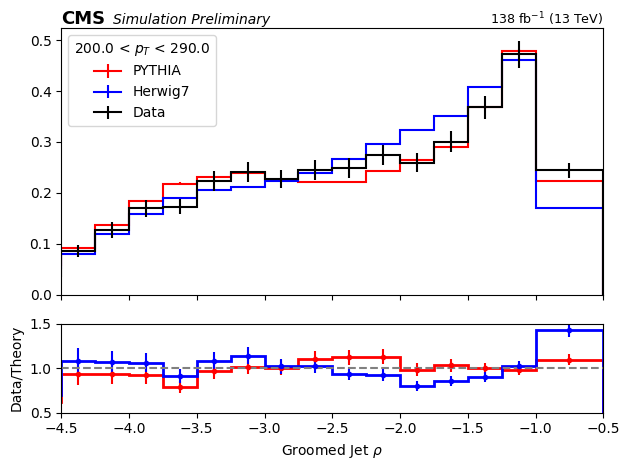

/home/cms-jovyan/GluonJetMass/unfold/notebooks/../utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/home/cms-jovyan/GluonJetMass/unfold/notebooks/../utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():


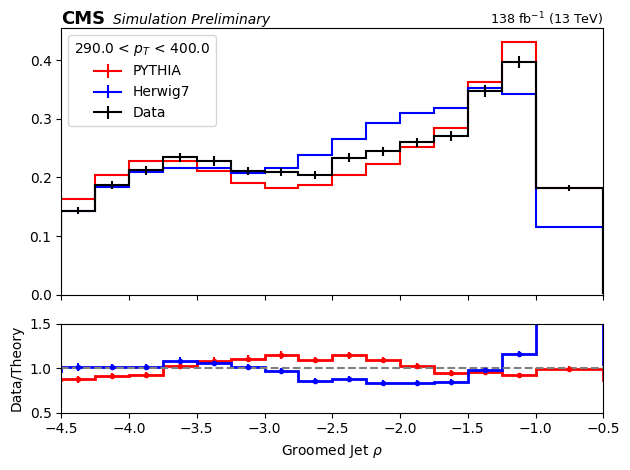

/home/cms-jovyan/GluonJetMass/unfold/notebooks/../utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/home/cms-jovyan/GluonJetMass/unfold/notebooks/../utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():


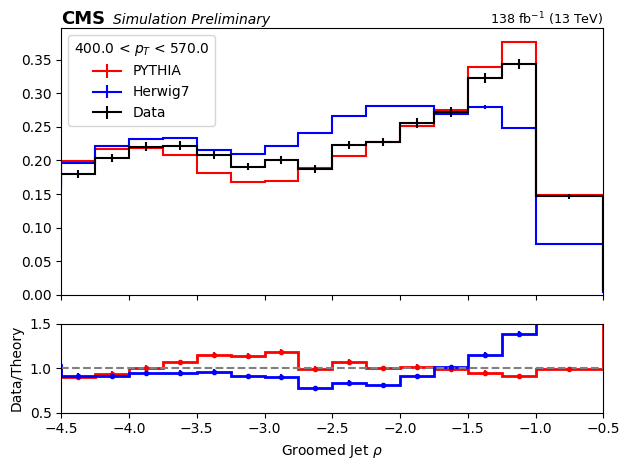

/home/cms-jovyan/GluonJetMass/unfold/notebooks/../utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/home/cms-jovyan/GluonJetMass/unfold/notebooks/../utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():


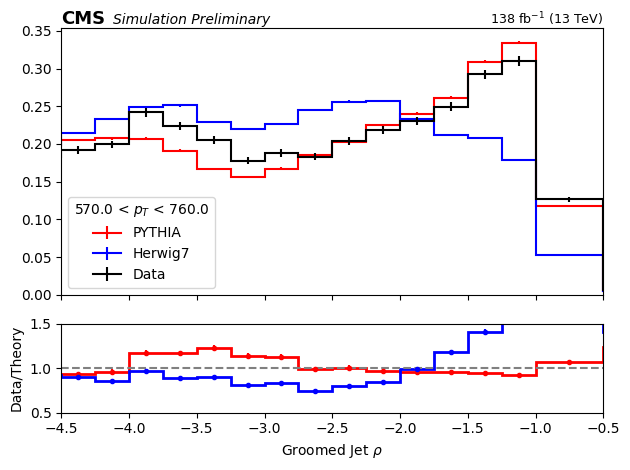

/home/cms-jovyan/GluonJetMass/unfold/notebooks/../utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/home/cms-jovyan/GluonJetMass/unfold/notebooks/../utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():


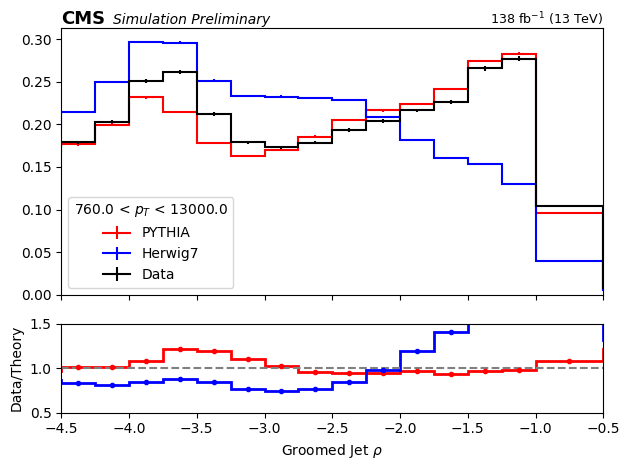

In [10]:
rlabel = r"138 fb$^{-1}$ (13 TeV)"
with open('../inputs/rho/jms_pythiaV2_all_syst.pkl', "rb") as f:
    output_pythia= pkl.load( f )

with open('../inputs/rho/rho_data_all.pkl', "rb") as f:
    output_data= pkl.load( f )

with open('../inputs/rho/herwig_all.pkl', "rb") as f:
    output_herwig= pkl.load( f )

groomed = True

bins = binning.bin_edges(groomed=groomed)
pt_edges = bins.pt_edges

for ipt in range(len(bins.pt_edges)-1):
    mreco_edge = bins.reco_rho_edges_by_pt[ipt]
    mreco_edge_new = mreco_edge.copy()


    
    mreco_width = np.diff(mreco_edge)
    

    fig, (ax_main, ax_ratio) = plt.subplots(2, 1, sharex=True,
                                              
                                              gridspec_kw={'height_ratios': [3, 1]})
    resp_matrix_4d = output_pythia['response_matrix_rho_u'] if not groomed else output_pythia['response_matrix_rho_g']
    resp_matrix_4d_herwig = output_herwig['response_matrix_rho_u'] if not groomed else output_herwig['response_matrix_rho_g']
    input_data = output_data['ptjet_rhojet_u_reco'] if not groomed else output_data['ptjet_rhojet_g_reco']

    # use rebin_hist to rebin the histograms to the mreco_edge 

    resp_matrix_4d = rebin_hist(resp_matrix_4d, 'mpt_reco', mreco_edge)
    resp_matrix_4d_herwig = rebin_hist(resp_matrix_4d_herwig, 'mpt_reco', mreco_edge)
    input_data = rebin_hist(input_data, 'mpt_reco', mreco_edge)
    
    mc_values = resp_matrix_4d.project('systematic','ptreco', 'mpt_reco')['nominal',ipt, :].values()
    mc_values_norm = mc_values/mreco_width/mc_values.sum()
    mc_stat =  resp_matrix_4d.project('systematic','ptreco', 'mpt_reco')['nominal',ipt, :].variances()**0.5
    mc_stat_norm = mc_stat/mreco_width/mc_values.sum()

    mc2_values = resp_matrix_4d_herwig.project('systematic','ptreco', 'mpt_reco')['nominal',ipt, :].values()
    mc2_values_norm = mc2_values/mreco_width/mc2_values.sum()
    mc2_stat =  resp_matrix_4d_herwig.project('systematic','ptreco', 'mpt_reco')['nominal',ipt, :].variances()**0.5
    mc2_stat_norm = mc2_stat/mreco_width/mc2_values.sum()

    
    data_values = input_data.project('ptreco', 'mpt_reco')[ipt, :].values()
    data_values_norm = data_values/mreco_width/data_values.sum()
    data_stat = input_data.project('ptreco', 'mpt_reco')[ipt, :].variances()**0.5
    data_stat_norm = data_stat/mreco_width/data_values.sum()


    ratio = np.divide(np.abs(mc_values_norm), np.abs(data_values_norm), out=np.ones_like(mc_values), where=data_values != 0)
    ratio2 = np.divide(np.abs(mc2_values_norm), np.abs(data_values_norm), out=np.ones_like(mc_values), where=data_values != 0)

    
    # hep.histplot(mc_values_norm, mreco_edge_new, yerr = mc_stat_norm, color = 'r',label = "PYTHIA", ax = ax_main)
    # hep.histplot(mc2_values_norm, mreco_edge_new, yerr = mc_stat_norm, color = 'b', label = "herwig7", ax = ax_main)
    # hep.histplot(data_values_norm, mreco_edge_new, yerr = data_stat_norm, color = 'k', label = "Data", ax = ax_main)
    # #ax_main.set_yscale('log')

    # print(data_values_norm)
    
    
    # plt.ylabel("#Events/GeV")
    # ax_main.legend(title = title_list[ipt])
    # xtick_labels = [str(int(tick)) for tick in mreco_edge_new]  # Convert to string
    # xtick_labels[-1] = r"$\infty$"  # Replace last label with infinity
    # plt.tick_params(axis='x', which='minor', top=False, bottom=False)
    # hep.cms.label("Preliminary", rlabel = rlabel, ax = ax_main)

    # #ax_main.set_yscale('log')



    # ax_ratio.stairs(ratio, mreco_edge_new, label="PYTHIA", color='r', lw= 2)
    # ax_ratio.stairs(ratio2, mreco_edge_new, label="PYTHIA", color='b', lw= 2)
    # ax_ratio.axhline(1, color='gray', linestyle='--')  # Reference line at 1
    mreco_edge_new = np.array(mreco_edge_new)
    # --- Main plots ---
    hep.histplot(mc_values_norm, mreco_edge_new, yerr=mc_stat_norm,
                 color='r', label="PYTHIA", ax=ax_main)
    hep.histplot(mc2_values_norm, mreco_edge_new, yerr=mc2_stat_norm,
                 color='b', label="Herwig7", ax=ax_main)
    hep.histplot(data_values_norm, mreco_edge_new, yerr=data_stat_norm,
                 color='k', label="Data", ax=ax_main)
    
    plt.ylabel("#Events/GeV")
    ax_main.legend(title=fr"{pt_edges[ipt]} < $p_T$ < {pt_edges[ipt+1]}")
    xtick_labels = [str(int(tick)) for tick in mreco_edge_new]
    xtick_labels[-1] = r"$\infty$"
    plt.tick_params(axis='x', which='minor', top=False, bottom=False)
    hep.cms.label("Preliminary", rlabel=rlabel, ax=ax_main)
    
    # --- Ratio calculation ---
    ratio1 = data_values_norm / mc_values_norm
    ratio2 = data_values_norm / mc2_values_norm
    
    # Error propagation
    ratio1_err = ratio1 * np.sqrt(
        (data_stat_norm / data_values_norm)**2 +
        (mc_stat_norm / mc_values_norm)**2
    )
    ratio2_err = ratio2 * np.sqrt(
        (data_stat_norm / data_values_norm)**2 +
        (mc2_stat_norm / mc2_values_norm)**2
    )
    
    # --- Ratio plots ---
    ax_ratio.stairs(ratio1, mreco_edge_new, label="PYTHIA", color='r', lw=2)
    ax_ratio.errorbar(
        0.5 * np.array(mreco_edge_new[1:] + mreco_edge_new[:-1]),  # bin centers
        ratio1,
        yerr=ratio1_err,
        fmt='.',
        color='r',

    )
    
    ax_ratio.stairs(ratio2, mreco_edge_new, label="Herwig7", color='b', lw=2)
    ax_ratio.errorbar(
        0.5 * np.array(mreco_edge_new[1:] + mreco_edge_new[:-1]),
        ratio2,
        yerr=ratio2_err,
        fmt='.',
        color='b'
    )
    
    ax_ratio.axhline(1, color='gray', linestyle='--')  # Reference line

    if not groomed:
        ax_ratio.set_xlabel(r"Ungroomed Jet $\rho$")
    else:
        ax_ratio.set_xlabel(r"Groomed Jet $\rho$")
    
    ax_ratio.set_ylabel("Data/Theory")
    ax_ratio.set_ylim(0.5, 1.5)
    ax_ratio.set_xlim(-4.5, -0.5)
    
    plt.tight_layout()


    # if groomed:
    #     plt.savefig(f'plots/unfold/input_groomed_{ipt}.pdf')
    # else:
    #     plt.savefig(f'plots/unfold/input_ungroomed_{ipt}.pdf')
    # #plt.xticks(mreco_edge_new, xtick_labels)
    plt.show()

/home/cms-jovyan/GluonJetMass/unfold/notebooks/../utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/home/cms-jovyan/GluonJetMass/unfold/notebooks/../utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():
/tmp/ipykernel_151/1134054440.py:97: RuntimeWarning: invalid value encountered in divide
  ratio1 = data_values_norm / mc_values_norm
/tmp/ipykernel_151/1134054440.py:98: RuntimeWarning: invalid value encountered in divide
  ratio2 = data_values_norm / mc2_values_norm
/tmp/ipykernel_151/1134054440.py:102: RuntimeWarning: invalid value encountered in divide
  (data_stat_norm / data_values_norm)**2 +
/tmp/ipykernel_151/1134054440.py:103: RuntimeWarning: invalid value encountered 

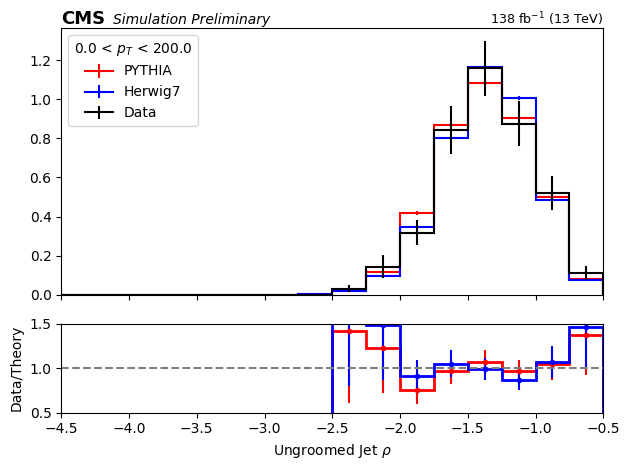

/home/cms-jovyan/GluonJetMass/unfold/notebooks/../utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/home/cms-jovyan/GluonJetMass/unfold/notebooks/../utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():
/tmp/ipykernel_151/1134054440.py:97: RuntimeWarning: invalid value encountered in divide
  ratio1 = data_values_norm / mc_values_norm
/tmp/ipykernel_151/1134054440.py:98: RuntimeWarning: invalid value encountered in divide
  ratio2 = data_values_norm / mc2_values_norm
/tmp/ipykernel_151/1134054440.py:102: RuntimeWarning: invalid value encountered in divide
  (data_stat_norm / data_values_norm)**2 +
/tmp/ipykernel_151/1134054440.py:103: RuntimeWarning: invalid value encountered 

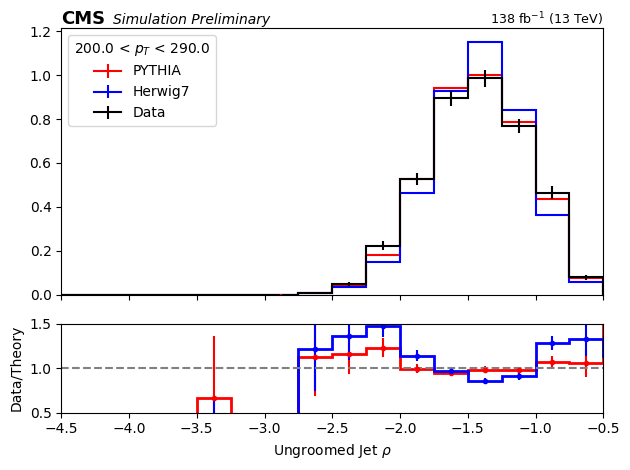

/home/cms-jovyan/GluonJetMass/unfold/notebooks/../utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/home/cms-jovyan/GluonJetMass/unfold/notebooks/../utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():
/tmp/ipykernel_151/1134054440.py:97: RuntimeWarning: invalid value encountered in divide
  ratio1 = data_values_norm / mc_values_norm
/tmp/ipykernel_151/1134054440.py:98: RuntimeWarning: invalid value encountered in divide
  ratio2 = data_values_norm / mc2_values_norm
/tmp/ipykernel_151/1134054440.py:102: RuntimeWarning: invalid value encountered in divide
  (data_stat_norm / data_values_norm)**2 +
/tmp/ipykernel_151/1134054440.py:103: RuntimeWarning: invalid value encountered 

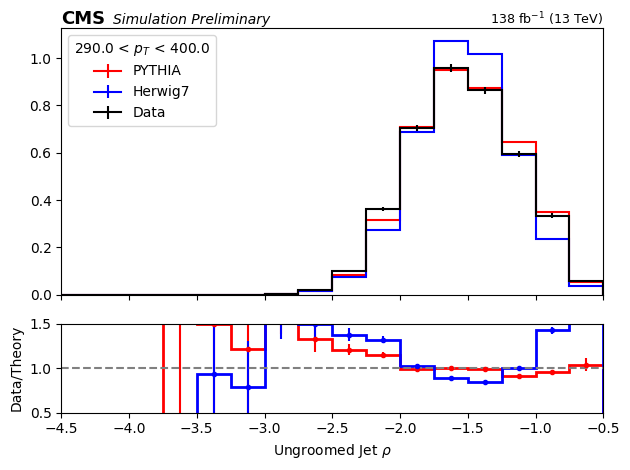

/home/cms-jovyan/GluonJetMass/unfold/notebooks/../utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/home/cms-jovyan/GluonJetMass/unfold/notebooks/../utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():
/tmp/ipykernel_151/1134054440.py:97: RuntimeWarning: invalid value encountered in divide
  ratio1 = data_values_norm / mc_values_norm
/tmp/ipykernel_151/1134054440.py:98: RuntimeWarning: invalid value encountered in divide
  ratio2 = data_values_norm / mc2_values_norm
/tmp/ipykernel_151/1134054440.py:102: RuntimeWarning: invalid value encountered in divide
  (data_stat_norm / data_values_norm)**2 +
/tmp/ipykernel_151/1134054440.py:103: RuntimeWarning: invalid value encountered 

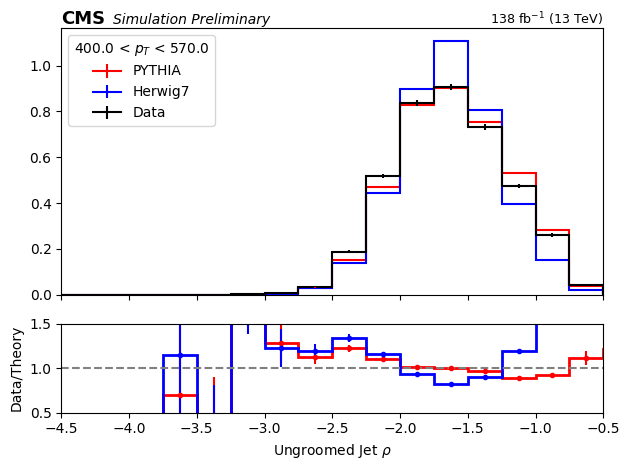

/home/cms-jovyan/GluonJetMass/unfold/notebooks/../utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/home/cms-jovyan/GluonJetMass/unfold/notebooks/../utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():
/tmp/ipykernel_151/1134054440.py:97: RuntimeWarning: invalid value encountered in divide
  ratio1 = data_values_norm / mc_values_norm
/tmp/ipykernel_151/1134054440.py:98: RuntimeWarning: invalid value encountered in divide
  ratio2 = data_values_norm / mc2_values_norm
/tmp/ipykernel_151/1134054440.py:102: RuntimeWarning: invalid value encountered in divide
  (data_stat_norm / data_values_norm)**2 +
/tmp/ipykernel_151/1134054440.py:103: RuntimeWarning: invalid value encountered 

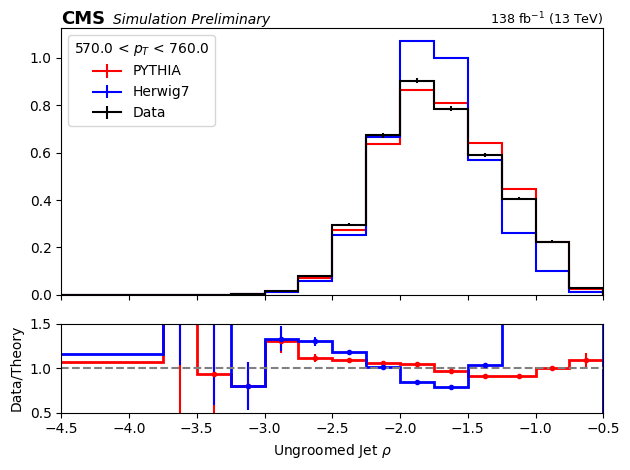

/home/cms-jovyan/GluonJetMass/unfold/notebooks/../utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/home/cms-jovyan/GluonJetMass/unfold/notebooks/../utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():
/tmp/ipykernel_151/1134054440.py:97: RuntimeWarning: divide by zero encountered in divide
  ratio1 = data_values_norm / mc_values_norm
/tmp/ipykernel_151/1134054440.py:97: RuntimeWarning: invalid value encountered in divide
  ratio1 = data_values_norm / mc_values_norm
/tmp/ipykernel_151/1134054440.py:98: RuntimeWarning: invalid value encountered in divide
  ratio2 = data_values_norm / mc2_values_norm
/tmp/ipykernel_151/1134054440.py:102: RuntimeWarning: invalid value encountere

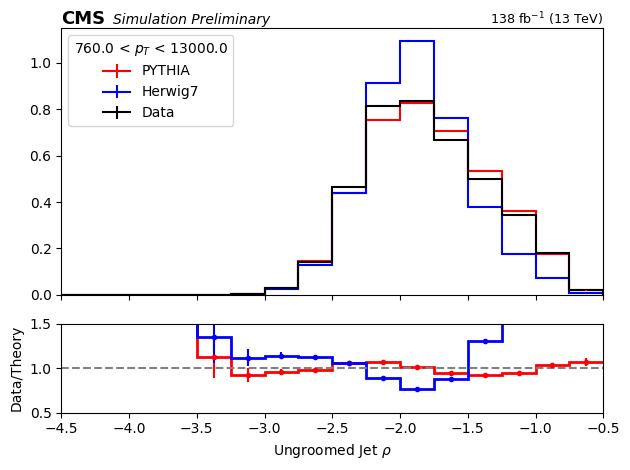

In [13]:
rlabel = r"138 fb$^{-1}$ (13 TeV)"
with open('../inputs/rho/jms_pythiaV2_all_syst.pkl', "rb") as f:
    output_pythia= pkl.load( f )

with open('../inputs/rho/rho_data_all.pkl', "rb") as f:
    output_data= pkl.load( f )

with open('../inputs/rho/herwig_all.pkl', "rb") as f:
    output_herwig= pkl.load( f )

groomed = False

bins = binning.bin_edges(groomed=groomed)

for ipt in range(len(pt_edges)-1):
    mreco_edge = bins.reco_rho_edges_by_pt[ipt]
    mreco_edge_new = mreco_edge.copy()


    
    mreco_width = np.diff(mreco_edge)
    

    fig, (ax_main, ax_ratio) = plt.subplots(2, 1, sharex=True,
                                              
                                              gridspec_kw={'height_ratios': [3, 1]})
    resp_matrix_4d = output_pythia['response_matrix_rho_u'] if not groomed else output_pythia['response_matrix_rho_g']
    resp_matrix_4d_herwig = output_herwig['response_matrix_rho_u'] if not groomed else output_herwig['response_matrix_rho_g']
    input_data = output_data['ptjet_rhojet_u_reco'] if not groomed else output_data['ptjet_rhojet_g_reco']

    # use rebin_hist to rebin the histograms to the mreco_edge 

    resp_matrix_4d = rebin_hist(resp_matrix_4d, 'mpt_reco', mreco_edge)
    resp_matrix_4d_herwig = rebin_hist(resp_matrix_4d_herwig, 'mpt_reco', mreco_edge)
    input_data = rebin_hist(input_data, 'mpt_reco', mreco_edge)
    
    mc_values = resp_matrix_4d.project('systematic','ptreco', 'mpt_reco')['nominal',ipt, :].values()
    mc_values_norm = mc_values/mreco_width/mc_values.sum()
    mc_stat =  resp_matrix_4d.project('systematic','ptreco', 'mpt_reco')['nominal',ipt, :].variances()**0.5
    mc_stat_norm = mc_stat/mreco_width/mc_values.sum()

    mc2_values = resp_matrix_4d_herwig.project('systematic','ptreco', 'mpt_reco')['nominal',ipt, :].values()
    mc2_values_norm = mc2_values/mreco_width/mc2_values.sum()
    mc2_stat =  resp_matrix_4d_herwig.project('systematic','ptreco', 'mpt_reco')['nominal',ipt, :].variances()**0.5
    mc2_stat_norm = mc2_stat/mreco_width/mc2_values.sum()

    
    data_values = input_data.project('ptreco', 'mpt_reco')[ipt, :].values()
    data_values_norm = data_values/mreco_width/data_values.sum()
    data_stat = input_data.project('ptreco', 'mpt_reco')[ipt, :].variances()**0.5
    data_stat_norm = data_stat/mreco_width/data_values.sum()


    ratio = np.divide(np.abs(mc_values_norm), np.abs(data_values_norm), out=np.ones_like(mc_values), where=data_values != 0)
    ratio2 = np.divide(np.abs(mc2_values_norm), np.abs(data_values_norm), out=np.ones_like(mc_values), where=data_values != 0)

    
    # hep.histplot(mc_values_norm, mreco_edge_new, yerr = mc_stat_norm, color = 'r',label = "PYTHIA", ax = ax_main)
    # hep.histplot(mc2_values_norm, mreco_edge_new, yerr = mc_stat_norm, color = 'b', label = "herwig7", ax = ax_main)
    # hep.histplot(data_values_norm, mreco_edge_new, yerr = data_stat_norm, color = 'k', label = "Data", ax = ax_main)
    # #ax_main.set_yscale('log')

    # print(data_values_norm)
    
    
    # plt.ylabel("#Events/GeV")
    # ax_main.legend(title = title_list[ipt])
    # xtick_labels = [str(int(tick)) for tick in mreco_edge_new]  # Convert to string
    # xtick_labels[-1] = r"$\infty$"  # Replace last label with infinity
    # plt.tick_params(axis='x', which='minor', top=False, bottom=False)
    # hep.cms.label("Preliminary", rlabel = rlabel, ax = ax_main)

    # #ax_main.set_yscale('log')



    # ax_ratio.stairs(ratio, mreco_edge_new, label="PYTHIA", color='r', lw= 2)
    # ax_ratio.stairs(ratio2, mreco_edge_new, label="PYTHIA", color='b', lw= 2)
    # ax_ratio.axhline(1, color='gray', linestyle='--')  # Reference line at 1
    mreco_edge_new = np.array(mreco_edge_new)
    # --- Main plots ---
    hep.histplot(mc_values_norm, mreco_edge_new, yerr=mc_stat_norm,
                 color='r', label="PYTHIA", ax=ax_main)
    hep.histplot(mc2_values_norm, mreco_edge_new, yerr=mc2_stat_norm,
                 color='b', label="Herwig7", ax=ax_main)
    hep.histplot(data_values_norm, mreco_edge_new, yerr=data_stat_norm,
                 color='k', label="Data", ax=ax_main)
    
    plt.ylabel("#Events/GeV")
    ax_main.legend(title=fr"{pt_edges[ipt]} < $p_T$ < {pt_edges[ipt+1]}")
    xtick_labels = [str(int(tick)) for tick in mreco_edge_new]
    xtick_labels[-1] = r"$\infty$"
    plt.tick_params(axis='x', which='minor', top=False, bottom=False)
    hep.cms.label("Preliminary", rlabel=rlabel, ax=ax_main)
    
    # --- Ratio calculation ---
    ratio1 = data_values_norm / mc_values_norm
    ratio2 = data_values_norm / mc2_values_norm
    
    # Error propagation
    ratio1_err = ratio1 * np.sqrt(
        (data_stat_norm / data_values_norm)**2 +
        (mc_stat_norm / mc_values_norm)**2
    )
    ratio2_err = ratio2 * np.sqrt(
        (data_stat_norm / data_values_norm)**2 +
        (mc2_stat_norm / mc2_values_norm)**2
    )
    
    # --- Ratio plots ---
    ax_ratio.stairs(ratio1, mreco_edge_new, label="PYTHIA", color='r', lw=2)
    ax_ratio.errorbar(
        0.5 * np.array(mreco_edge_new[1:] + mreco_edge_new[:-1]),  # bin centers
        ratio1,
        yerr=ratio1_err,
        fmt='.',
        color='r',

    )
    
    ax_ratio.stairs(ratio2, mreco_edge_new, label="Herwig7", color='b', lw=2)
    ax_ratio.errorbar(
        0.5 * np.array(mreco_edge_new[1:] + mreco_edge_new[:-1]),
        ratio2,
        yerr=ratio2_err,
        fmt='.',
        color='b'
    )
    
    ax_ratio.axhline(1, color='gray', linestyle='--')  # Reference line

    if not groomed:
        ax_ratio.set_xlabel(r"Ungroomed Jet $\rho$")
    else:
        ax_ratio.set_xlabel(r"Groomed Jet $\rho$")
    
    ax_ratio.set_ylabel("Data/Theory")
    ax_ratio.set_ylim(0.5, 1.5)
    ax_ratio.set_xlim(-4.5, -0.5)
    
    plt.tight_layout()


    # if groomed:
    #     plt.savefig(f'plots/unfold/input_groomed_{ipt}.pdf')
    # else:
    #     plt.savefig(f'plots/unfold/input_ungroomed_{ipt}.pdf')
    # #plt.xticks(mreco_edge_new, xtick_labels)
    plt.show()